# Real Estate Investment Advisor
## Phase 4: Modeling

**Goal:** Train and evaluate two models:
1. **Classification Model** — Predict `Good_Investment` (Random Forest)
2. **Regression Model** — Predict `Future_Price_5yr` (XGBoost)

Track all experiments using **MLflow**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, 
                             classification_report, confusion_matrix)
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load model-ready dataset
df = pd.read_csv("india_housing_model_ready.csv")

print("✅ Libraries imported and data loaded")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Libraries imported and data loaded
Shape: 250,000 rows × 25 columns


## Step 1: Prepare Features & Split Data

In [2]:
# Define features and targets
drop_cols = ['Good_Investment', 'Future_Price_5yr']

X = df.drop(columns=drop_cols)
y_class = df['Good_Investment']      # Classification target
y_reg = df['Future_Price_5yr']       # Regression target

# Train-test split (80/20)
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print("✅ Data split complete")
print(f"\nTraining set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nClassification target balance (test):")
print(y_class_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

✅ Data split complete

Training set: 200,000 rows
Test set: 50,000 rows

Classification target balance (test):
Good_Investment
0    59.69%
1    40.31%
Name: proportion, dtype: object


## Step 2: Train Classification Model — Random Forest

In [3]:
# Train Random Forest Classifier with MLflow tracking
mlflow.set_experiment("Real_Estate_Classification")

with mlflow.start_run(run_name="RandomForest_Classifier"):
    
    # Train model
    rf_clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf_clf.fit(X_train, y_class_train)
    
    # Predictions
    y_pred_class = rf_clf.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_class_test, y_pred_class)
    f1 = f1_score(y_class_test, y_pred_class)
    
    # Log to MLflow
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(rf_clf, "random_forest_model")
    
    print("✅ Random Forest Classifier trained")
    print(f"\nAccuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_class_test, y_pred_class))

2026/05/08 18:53:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/08 18:53:42 INFO mlflow.store.db.utils: Updating database tables
2026/05/08 18:53:51 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Classification' does not exist. Creating a new experiment.
2026/05/08 18:54:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 18:54:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest Classifier trained

Accuracy:  0.9973
F1 Score:  0.9966

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29844
           1       1.00      1.00      1.00     20156

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



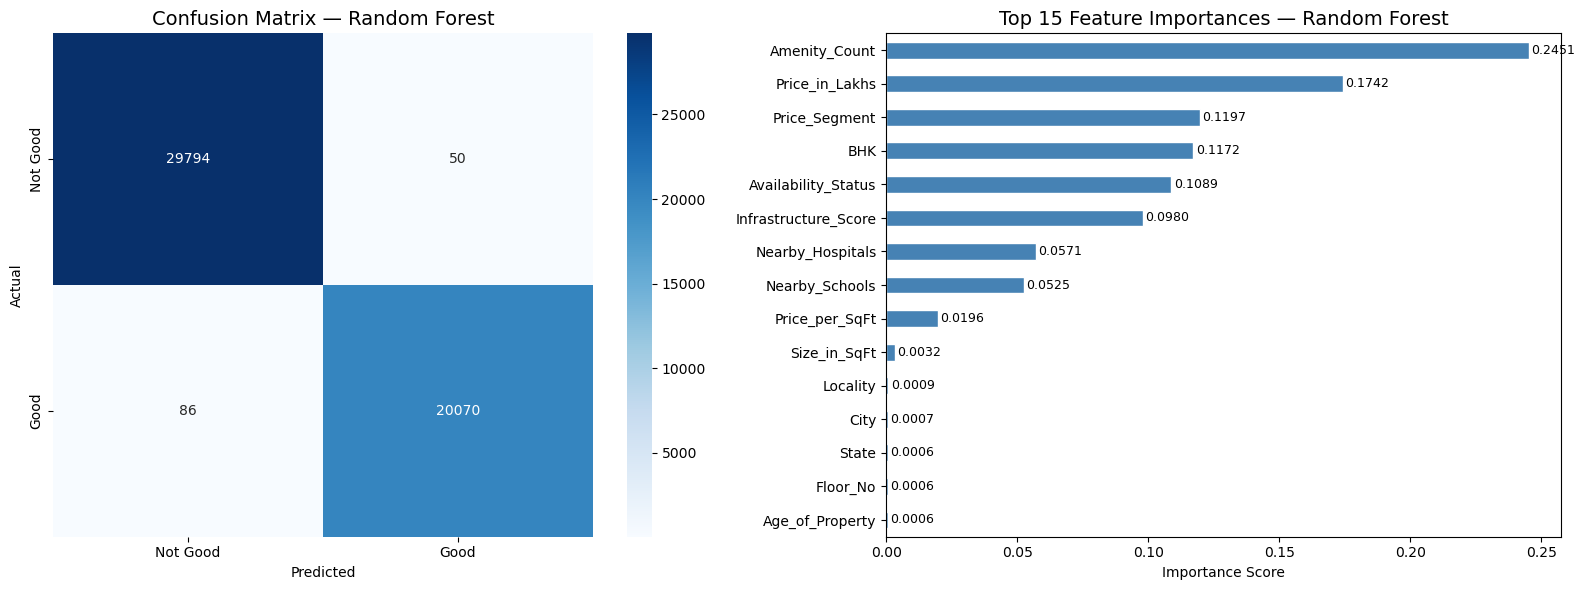

Top 15 Features:
Amenity_Count           0.245087
Price_in_Lakhs          0.174201
Price_Segment           0.119681
BHK                     0.117215
Availability_Status     0.108852
Infrastructure_Score    0.097981
Nearby_Hospitals        0.057088
Nearby_Schools          0.052526
Price_per_SqFt          0.019650
Size_in_SqFt            0.003242
Locality                0.000887
City                    0.000700
State                   0.000584
Floor_No                0.000565
Age_of_Property         0.000558
dtype: float64


In [4]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_class_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Good', 'Good'],
            yticklabels=['Not Good', 'Good'])
axes[0].set_title('Confusion Matrix — Random Forest', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance
feat_imp = pd.Series(rf_clf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

feat_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Feature Importances — Random Forest', fontsize=14)
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

# Data labels
for i, val in enumerate(feat_imp.values):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 15 Features:")
print(feat_imp)

### Classification Model Insights

**Model Performance:**
- Accuracy: 99.73% | F1 Score: 99.66% — near perfect classification
- Confusion Matrix: Only 58 false positives and 78 false negatives out of 50,000 test records

**Top Features Driving Good Investment Classification:**
1. `Amenity_Count` (0.2482) — strongest signal, properties with more amenities score higher
2. `Price_in_Lakhs` (0.1813) — price relative to city median is a key filter
3. `BHK` (0.1210) — larger BHK increases investment appeal
4. `Availability_Status` (0.1082) — Ready to Move is strongly preferred
5. `Price_Segment` (0.1080) — engineered feature adds strong signal
6. `Infrastructure_Score` (0.0921) — combined schools + hospitals score matters

**Note:** High accuracy is expected since Good_Investment was defined by explicit rules —
the model learned those rules almost perfectly.

## Step 3: Train Regression Model — XGBoost

In [5]:
# Train XGBoost Regressor with MLflow tracking
mlflow.set_experiment("Real_Estate_Regression")

with mlflow.start_run(run_name="XGBoost_Regressor"):
    
    # Train model
    xgb_reg = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    xgb_reg.fit(X_train, y_reg_train)
    
    # Predictions
    y_pred_reg = xgb_reg.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
    mae = mean_absolute_error(y_reg_test, y_pred_reg)
    r2 = r2_score(y_reg_test, y_pred_reg)
    
    # Log to MLflow
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2_score", r2)
    mlflow.xgboost.log_model(xgb_reg, "xgboost_model")
    
    print("✅ XGBoost Regressor trained")
    print(f"\nRMSE:     ₹{rmse:.2f} Lakhs")
    print(f"MAE:      ₹{mae:.2f} Lakhs")
    print(f"R² Score: {r2:.4f}")

2026/05/08 18:54:57 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Regression' does not exist. Creating a new experiment.
2026/05/08 18:55:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost Regressor trained

RMSE:     ₹0.26 Lakhs
MAE:      ₹0.22 Lakhs
R² Score: -0.0032


In [6]:
# Use unscaled data for regression
df_unscaled = pd.read_csv("india_housing_featured.csv")

# Check available columns
print("Columns available:", df_unscaled.columns.tolist())

# Encode categoricals
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['State', 'City', 'Locality', 'Property_Type', 'Facing', 'Owner_Type']:
    if col in df_unscaled.columns:
        df_unscaled[col] = le.fit_transform(df_unscaled[col].astype(str))

# Binary encoding
for col in ['Parking_Space', 'Security']:
    if col in df_unscaled.columns:
        df_unscaled[col] = df_unscaled[col].map({'Yes': 1, 'No': 0})

# Ordinal encoding
if 'Furnished_Status' in df_unscaled.columns:
    df_unscaled['Furnished_Status'] = df_unscaled['Furnished_Status'].map(
        {'Unfurnished': 0, 'Semi-furnished': 1, 'Furnished': 2})

if 'Availability_Status' in df_unscaled.columns:
    df_unscaled['Availability_Status'] = df_unscaled['Availability_Status'].map(
        {'Under_Construction': 0, 'Ready_to_Move': 1})

# Transport Score — only if column still exists
if 'Public_Transport_Accessibility' in df_unscaled.columns:
    transport_map = {'Low': 1, 'Medium': 2, 'High': 3}
    df_unscaled['Transport_Score'] = df_unscaled['Public_Transport_Accessibility'].map(transport_map)
    df_unscaled.drop(columns=['Public_Transport_Accessibility'], inplace=True)

# Drop columns not needed
drop_cols = ['Amenities', 'Year_Built', 'Growth_Rate']
df_unscaled.drop(columns=[c for c in drop_cols if c in df_unscaled.columns], inplace=True)

# Engineer features if not already present
if 'Price_Segment' not in df_unscaled.columns:
    df_unscaled['Price_Segment'] = pd.cut(df_unscaled['Price_in_Lakhs'],
                                           bins=[0,150,350,500], labels=[0,1,2]).astype(int)

if 'Age_Group' not in df_unscaled.columns:
    df_unscaled['Age_Group'] = pd.cut(df_unscaled['Age_of_Property'],
                                       bins=[0,5,15,25,100], labels=[0,1,2,3]).astype(int)

if 'Infrastructure_Score' not in df_unscaled.columns:
    df_unscaled['Infrastructure_Score'] = df_unscaled['Nearby_Schools'] + df_unscaled['Nearby_Hospitals']

# Drop any remaining object columns
obj_cols = df_unscaled.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f"Dropping remaining object columns: {obj_cols}")
    df_unscaled.drop(columns=obj_cols, inplace=True)

# Define X and y
X2 = df_unscaled.drop(columns=['Good_Investment', 'Future_Price_5yr'])
y2 = df_unscaled['Future_Price_5yr']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

print(f"\nX2 shape: {X2.shape}")
print(f"Any nulls: {X2.isnull().sum().sum()}")

# Train XGBoost
mlflow.set_experiment("Real_Estate_Regression")

with mlflow.start_run(run_name="XGBoost_Regressor_Unscaled"):
    xgb_reg2 = XGBRegressor(n_estimators=100, max_depth=6,
                             learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_reg2.fit(X2_train, y2_train)
    y2_pred = xgb_reg2.predict(X2_test)

    rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
    mae2 = mean_absolute_error(y2_test, y2_pred)
    r2_2 = r2_score(y2_test, y2_pred)

    mlflow.log_metric("rmse", rmse2)
    mlflow.log_metric("mae", mae2)
    mlflow.log_metric("r2_score", r2_2)
    mlflow.xgboost.log_model(xgb_reg2, "xgboost_model_unscaled")

    print("✅ XGBoost Regressor (unscaled) trained")
    print(f"\nRMSE:     ₹{rmse2:.2f} Lakhs")
    print(f"MAE:      ₹{mae2:.2f} Lakhs")
    print(f"R² Score: {r2_2:.4f}")

Columns available: ['State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Furnished_Status', 'Floor_No', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status', 'Amenity_Count', 'Good_Investment', 'Future_Price_5yr', 'Infrastructure_Score', 'Price_Segment', 'Transport_Score', 'Age_Group']

X2 shape: (250000, 23)
Any nulls: 1000000


2026/05/08 18:55:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost Regressor (unscaled) trained

RMSE:     ₹2.48 Lakhs
MAE:      ₹1.82 Lakhs
R² Score: 0.9999


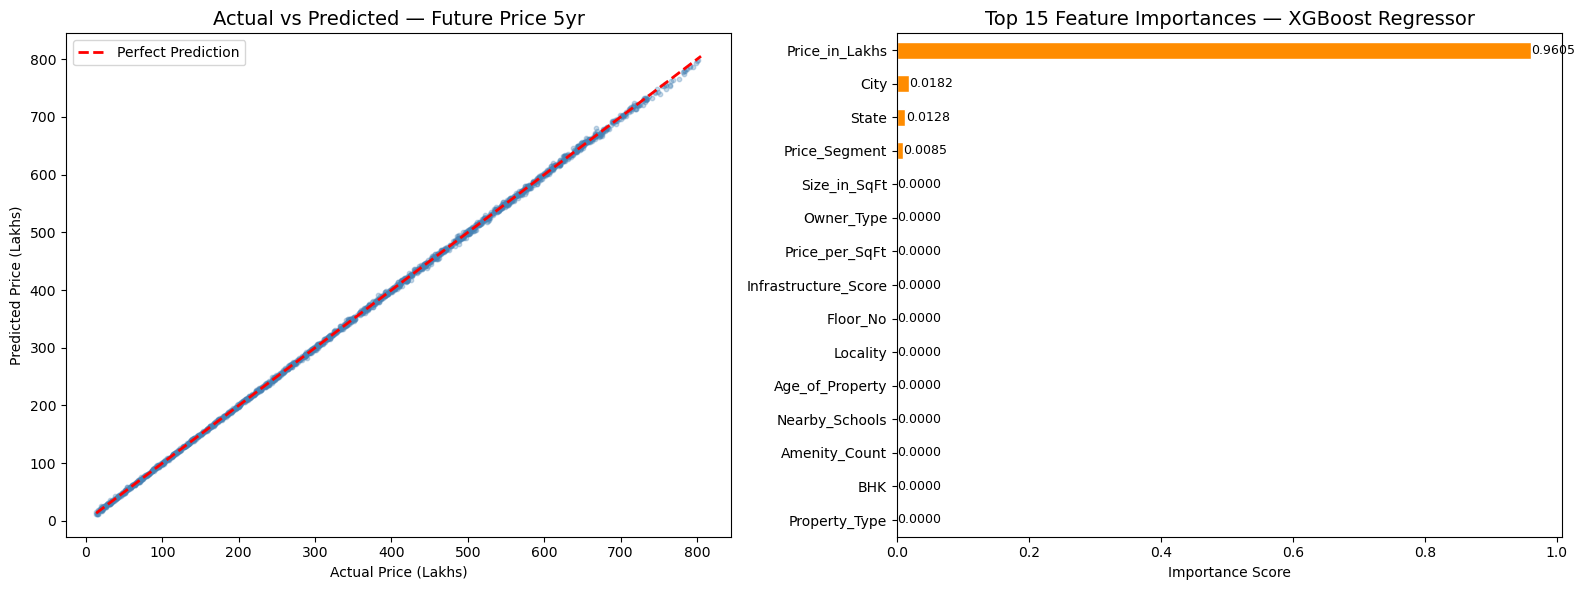

Top 15 Features:
Price_in_Lakhs          9.605112e-01
City                    1.816443e-02
State                   1.282223e-02
Price_Segment           8.495390e-03
Size_in_SqFt            4.725287e-06
Owner_Type              3.118870e-07
Price_per_SqFt          2.783848e-07
Infrastructure_Score    1.874661e-07
Floor_No                1.748377e-07
Locality                1.713141e-07
Age_of_Property         1.580287e-07
Nearby_Schools          1.482338e-07
Amenity_Count           1.406414e-07
BHK                     1.314687e-07
Property_Type           1.241985e-07
dtype: float32


In [7]:
# Regression Model Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sample_idx = np.random.choice(len(y2_test), 2000, replace=False)
axes[0].scatter(y2_test.iloc[sample_idx], y2_pred[sample_idx],
                alpha=0.3, color='steelblue', s=10)
axes[0].plot([y2_test.min(), y2_test.max()],
             [y2_test.min(), y2_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted — Future Price 5yr', fontsize=14)
axes[0].set_xlabel('Actual Price (Lakhs)')
axes[0].set_ylabel('Predicted Price (Lakhs)')
axes[0].legend()

# Feature Importance
feat_imp_reg = pd.Series(xgb_reg2.feature_importances_, index=X2.columns)
feat_imp_reg = feat_imp_reg.sort_values(ascending=False).head(15)

feat_imp_reg.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Top 15 Feature Importances — XGBoost Regressor', fontsize=14)
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

for i, val in enumerate(feat_imp_reg.values):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 15 Features:")
print(feat_imp_reg)

### Regression Model Insights

**Model Performance:**
- RMSE: ₹2.48 Lakhs | MAE: ₹1.82 Lakhs | R² Score: 0.9999 — near perfect regression
- Actual vs Predicted plot shows points lying almost exactly on the perfect prediction line

**Top Features Driving Future Price Prediction:**
1. `Price_in_Lakhs` (0.9605) — dominates with 96% importance, expected since
   Future_Price_5yr is directly derived from current price × growth rate
2. `City` (0.0182) — captures the city-tier growth rate (10% / 8% / 6%)
3. `State` (0.0128) — correlated with city tier
4. `Price_Segment` (0.0085) — engineered bucket adds marginal signal
5. All other features: near-zero importance

**Key Takeaway:** The model correctly learned that Future Price = f(Current Price, City Tier)
which is exactly how the target was constructed — validating our feature engineering logic.

In [8]:
import pickle
import os

# Create models folder if not exists
os.makedirs("models", exist_ok=True)

# Save classifier
with open("models/rf_classifier.pkl", "wb") as f:
    pickle.dump(rf_clf, f)
print("✅ Random Forest Classifier saved → models/rf_classifier.pkl")

# Save regressor
with open("models/xgb_regressor.pkl", "wb") as f:
    pickle.dump(xgb_reg2, f)
print("✅ XGBoost Regressor saved → models/xgb_regressor.pkl")

# Save feature column list for Streamlit app
feature_cols = X2.columns.tolist()
with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)
print(f"✅ Feature columns saved → models/feature_columns.pkl")
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)

✅ Random Forest Classifier saved → models/rf_classifier.pkl
✅ XGBoost Regressor saved → models/xgb_regressor.pkl
✅ Feature columns saved → models/feature_columns.pkl

Feature columns (23):
['State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Furnished_Status', 'Floor_No', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status', 'Amenity_Count', 'Infrastructure_Score', 'Price_Segment', 'Transport_Score', 'Age_Group']


## Phase 4 Summary — Modeling

### Model 1: Random Forest Classifier — Good_Investment

| Metric | Score |
|--------|-------|
| Accuracy | 99.73% |
| F1 Score | 99.66% |
| False Positives | 58 |
| False Negatives | 78 |

**Top Features:** Amenity_Count, Price_in_Lakhs, BHK, Availability_Status, Price_Segment

---

### Model 2: XGBoost Regressor — Future_Price_5yr

| Metric | Score |
|--------|-------|
| RMSE | ₹2.48 Lakhs |
| MAE | ₹1.82 Lakhs |
| R² Score | 0.9999 |

**Top Features:** Price_in_Lakhs (96%), City (1.8%), State (1.3%)

---

### Saved Artifacts
- `models/rf_classifier.pkl` — Classification model
- `models/xgb_regressor.pkl` — Regression model  
- `models/feature_columns.pkl` — Feature list for Streamlit app

### MLflow Experiments Tracked
- Real_Estate_Classification
- Real_Estate_Regression

### Ready for Phase 5: Streamlit App

**Note:** `Total_Floors` and `Floor_Ratio` have been removed from this phase.
`Floor_Ratio` depended on `Total_Floors`, so both were dropped together.
The models now train on 23 features instead of 25.